In [90]:
#SECTION 1.1 + 1.2

#importing required packages
import os
import pandas as pd

#creating project file path
file_path = r"C:\Users\amina\PycharmProjects\LungCancerAnalysis"

#changing working directory and listing contents
os.chdir(file_path)
print("current working directory:", os.getcwd())
print("directory contents:", os.listdir())

current working directory: C:\Users\amina\PycharmProjects\LungCancerAnalysis
directory contents: ['.idea', '.venv', 'age_tumor_size.png', 'bmi_trial_drug.png', 'correlation_heatmap.png', 'LungCancerAnalysis.ipynb', 'lung_cancer_clinical_trial.csv', 'lung_cancer_processed.xlsx', 'numerical_pairplot.png', 'risk_level_county.png', 'tumour_stage_gender.png']


In [64]:
                             #Section 1.3

#storing dataset as a variable and reading it in
dataset_filename = "lung_cancer_clinical_trial.csv"
df_og = pd.read_csv(dataset_filename)

#exploring the df
print(df_og.shape)
print(df_og.columns)
print(df_og.dtypes)
missing_values = df_og.isnull().sum()
print(f"There are {missing_values} missing values")

#printing value counts for categorical variables
print(df_og['Gender'].value_counts())
print(df_og['Smoking_History'].value_counts())
print(df_og['Tumor_Stage'].value_counts())
print(df_og['County'].value_counts())


(300, 17)
Index(['Age', 'Gender', 'Smoking_History', 'Family_History_Lung_Cancer',
       'Genetic_Mutation_EGFR', 'Genetic_Mutation_ALK', 'Tumor_Stage',
       'Tumor_Size_cm', 'Treatment_Type', 'Response_to_Treatment',
       'Blood_Hemoglobin_gdL', 'White_Blood_Cell_thousand_per_microliter',
       'Radiation_Exposure', 'Environmental_Exposure', 'Comorbidities', 'BMI',
       'County'],
      dtype='str')
Age                                           int64
Gender                                          str
Smoking_History                                 str
Family_History_Lung_Cancer                      str
Genetic_Mutation_EGFR                           str
Genetic_Mutation_ALK                            str
Tumor_Stage                                     str
Tumor_Size_cm                               float64
Treatment_Type                                  str
Response_to_Treatment                           str
Blood_Hemoglobin_gdL                        float64
White_Blood_Cell

In [65]:
#Section 1.4

#creating a subset of original df
numerical_columns = df_og[['Age', 'Tumor_Size_cm', 'Blood_Hemoglobin_gdL', 'White_Blood_Cell_thousand_per_microliter', 'BMI']]

#creating for loop to give mean and std for each column
for col in numerical_columns:
   mean = numerical_columns[col].mean()
   std = numerical_columns[col].std()
   print(f'{col} mean: {mean}')
   print(f'{col} std: {std}')

Age mean: 55.45333333333333
Age std: 12.165847622895026
Tumor_Size_cm mean: 6.088333333333333
Tumor_Size_cm std: 2.083322185031487
Blood_Hemoglobin_gdL mean: 11.490333333333334
Blood_Hemoglobin_gdL std: 1.458846805606968
White_Blood_Cell_thousand_per_microliter mean: 9.213
White_Blood_Cell_thousand_per_microliter std: 1.2995488025853448
BMI mean: 26.111333333333334
BMI std: 3.0020291168280107


In [66]:
#Section 1.5

#checking for duplicates
duplicates = df_og.duplicated()

if duplicates.any():
    print(f"number of duplicated rows: {duplicates.sum()}")
    df= df_og.drop_duplicates()
    print("duplicate rows removed.")
else:
    print("no duplicate rows found.")

print(df.shape)

number of duplicated rows: 30
duplicate rows removed.
(270, 17)


In [67]:
#Section 2. 1
"""
handling missing values with particular methods depending on whats the data type, then confirming it worked
"""
all_numeric_columns = ["Age","Tumor_Size_cm","Blood_Hemoglobin_gdL", "White_Blood_Cell_thousand_per_microliter","BMI"]

special_columns = ["Genetic_Mutation_EGFR","'Genetic_Mutation_ALK","Radiation_Exposure","Environmental_Exposure"]

while missing_values.sum() >0: #missing values df made in section 1

    for col in df:
        if df[col].isnull().any():

            if col in all_numeric_columns: #if na in numeric than median
                df[col] =df[col].fillna(df[col].median())
            elif col in special_columns: #if na in exceptions then unknown
                df[col] =df[col].fillna("Unknown")
            else: #if na in anything else than mode
                df[col] =df[col].fillna(df[col].mode()[0])
    missing_values = df.isnull().sum()

#triplle checking it worked
print("Na values remaining:", missing_values.sum())
#df.to_csv("updated_data(2).csv", index=False)
#wow that actually worked am amazed




Na values remaining: 0


In [69]:
#Section 2.2

"""
Tumour staging done with roman numerals from 1-4, this code checks if anything else is present and if it is it replaces it with the mode value
"""

mode_Tumor_Stage= df["Tumor_Stage"].mode()[0]
print(mode_Tumor_Stage)

for i in df["Tumor_Stage"]:
    if i in ["I", "II", "III", "IV"]:
        print("No invalid entry found")
        continue
    else:
        print(f"Invalid entry found: {i}")
        df["Tumor_Stage"] =df["Tumor_Stage"].replace(i,mode_Tumor_Stage)

III
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No invalid entry found
No inva

In [71]:
#Section 2.3

median_Tumor_Size_cm = df["Tumor_Size_cm"].median()
#print(median_Tumor_Size_cm)
#Tumour_Size_cm_outliers = ((df["Tumor_Size_cm"] > 10) |  (df["Tumor_Size_cm"] < 0.5)).sum() #special pandas "or"
print(Tumour_Size_cm_outliers)

values_replaced = 0
for i in df["Tumor_Size_cm"]:
    if i > 10 or i <0.5:
        df["Tumor_Size_cm"] =df["Tumor_Size_cm"].replace(i,median_Tumor_Size_cm)
        values_replaced +=1

if values_replaced >0:
    print(f"{values_replaced} values in tumor size were replaced")
else:
    print("No values replaced")



0
No values replaced


In [72]:
#Section 2.4

#make a new empty column to put stuff in
df["Risk_Level"] = ""

#use loc method to access rows, using or here, need to check when or vs |
#i in df didnt work as you need to specificy iterate through rows
for i in df.index:
    if df.loc[i,"Smoking_History"] == "Current" and df.loc[i,"Environmental_Exposure"]== "Yes":
        df.loc[i, "Risk_Level"] = "High"
    elif df.loc[i,"Smoking_History"] == "Current" or df.loc[i,"Environmental_Exposure"]== "Yes":
        df.loc[i, "Risk_Level"] = "Medium"
    else:
        df.loc[i, "Risk_Level"] = "Low"
print(df['Risk_Level'].value_counts())



Risk_Level
Low       148
Medium    104
High       18
Name: count, dtype: int64


In [73]:
#Section 2.5
df["Severity_Label"] = ""

for i in df.index:
    if df.loc[i,"BMI"] > 25 and (df.loc[i,"Tumor_Stage"] == "III" or df.loc[i,"Tumor_Stage"] ==  "IV"):
        df.loc[i,"Severity_Label"] = "Severe"
    elif df.loc[i,"BMI"] <= 25 or (df.loc[i,"Tumor_Stage"] == "I" or df.loc[i,"Tumor_Stage"] ==  "II"):
        df.loc[i,"Severity_Label"] = "Moderate"
    else:
        df.loc[i,"Severity_Label"] = "Intermediate"
print(df["Tumor_Stage"].value_counts())

print(df[["BMI","Tumor_Stage","Severity_Label"]].head(20))

Tumor_Stage
III    76
IV     69
I      65
II     60
Name: count, dtype: int64
     BMI Tumor_Stage Severity_Label
0   25.7          IV         Severe
1   29.6          II       Moderate
2   29.4          IV         Severe
3   24.2         III       Moderate
4   29.3          IV         Severe
5   21.4          IV       Moderate
6   27.0          IV         Severe
7   23.3           I       Moderate
8   22.2         III       Moderate
9   21.8          IV       Moderate
10  28.0         III         Severe
11  24.4         III       Moderate
12  28.2         III         Severe
13  21.7          II       Moderate
14  24.2          IV       Moderate
15  26.4           I       Moderate
16  28.9           I       Moderate
17  24.2           I       Moderate
18  27.3           I       Moderate
19  29.9          IV         Severe


In [74]:
#Section 3.1

sort_data = []
county_group = df.groupby("County")
for county_name, group in county_group:
    mean_bmi = float(group["BMI"].mean())
    median_Tumour = float(group["Tumor_Size_cm"].median())
    patient_sum = len(group)
    sort_data.append([county_name,mean_bmi, median_Tumour, patient_sum])
# the code above is a for loop to group rows by county, after which the mean, median, and patient count are generated.
#The loop gives us this for each county, and it is placed into a list
df_sort = pd.DataFrame(sort_data, columns=["County", "Mean_BMI", "Median_Tumor", "Patient_Count"])
df_sort = df_sort.sort_values(by="Patient_Count", ascending=False).reset_index()
#using Pandas we can sort this converted dataframe, kaggle as resource
for i in range(len(df_sort)):
    county = df_sort.loc[i, "County"]
    mean_bmi = df_sort.loc[i, "Mean_BMI"]
    median_tumor = df_sort.loc[i, "Median_Tumor"]
    patient_count = df_sort.loc[i, "Patient_Count"]
    print(f"County: {county}, Mean BMI: {mean_bmi:.2f}, Median Tumor Size: {median_tumor:.2f} cm, Count: {patient_count}")
#another for loop to help print the f-string from dataframe

County: Dublin, Mean BMI: 25.77, Median Tumor Size: 5.90 cm, Count: 73
County: Cork, Mean BMI: 25.62, Median Tumor Size: 6.15 cm, Count: 72
County: Galway, Mean BMI: 26.62, Median Tumor Size: 6.35 cm, Count: 66
County: Limerick, Mean BMI: 26.52, Median Tumor Size: 6.50 cm, Count: 59


In [75]:
#Section 3.2
def summarize_risk_by_mutation(data, mutation, risk):
    cross_result = pd.crosstab(df[mutation], df[risk])
    return (cross_result)
test = summarize_risk_by_mutation(df, 'Genetic_Mutation_EGFR','Risk_Level')
print(test)

#function that crosstabulates EGFR mutation with Risk level and returns the result, this was then tested on the df

Risk_Level             High  Low  Medium
Genetic_Mutation_EGFR                   
Negative                  6   53      40
Positive                  3   42      27
Unknown                   9   53      37


In [76]:
#Section 3.3
import numpy as np
print(all_numeric_columns)
num_col = ["Age", "Tumor_Size_cm","Blood_Hemoglobin_gdL","White_Blood_Cell_thousand_per_microliter","BMI"]
corr_matrix = df[num_col].corr()
print(corr_matrix)
#first the correlation matrix is created
i = 0
while i < len(num_col):
    j = i + 1
    while j < len(num_col):
        corr_value = df[num_col[i]].corr(df[num_col[j]])
        if corr_value > 0.5 or corr_value < -0.5:
            print(f"Pair: ({num_col[i]}, {num_col[j]}), Correlation: {corr_value:.3f}")
        j += 1
    i += 1
#next a while loop is made to exist while the iterated columns remain below 5, which means until the pairwise correlations are completed


['Age', 'Tumor_Size_cm', 'Blood_Hemoglobin_gdL', 'White_Blood_Cell_thousand_per_microliter', 'BMI']
                                               Age  Tumor_Size_cm  \
Age                                       1.000000      -0.022284   
Tumor_Size_cm                            -0.022284       1.000000   
Blood_Hemoglobin_gdL                      0.005756       0.180712   
White_Blood_Cell_thousand_per_microliter -0.178635       0.111071   
BMI                                       0.002164      -0.009415   

                                          Blood_Hemoglobin_gdL  \
Age                                                   0.005756   
Tumor_Size_cm                                         0.180712   
Blood_Hemoglobin_gdL                                  1.000000   
White_Blood_Cell_thousand_per_microliter              0.104504   
BMI                                                  -0.022265   

                                          White_Blood_Cell_thousand_per_microliter  \
Ag

In [77]:
#Section 3.4
Treatment_group = df.groupby("Treatment_Type")
treat_results = []

for treatment_name, group in Treatment_group:
    mean_hemo = float(group["Blood_Hemoglobin_gdL"].mean())
    mean_white = float(group["White_Blood_Cell_thousand_per_microliter"].mean())
    if mean_hemo <10:
        print(f'Treatment: {treatment_name}, Status:Low Hemoglobin (red) Count({mean_hemo:.2f})')
    elif mean_white <10:
        print(f'Treatment: {treatment_name}, Status:Low Hemoglobin (white) Count({mean_white:.2f})')
    else:
        print(f'Treatment: {treatment_name}, Status is normal')
#this for loop calculates the mean for both blood cell columns when grouped by treatment type, and the if-elif-else determines the printed string


Treatment: Chemotherapy, Status:Low Hemoglobin (white) Count(9.29)
Treatment: Immunotherapy, Status:Low Hemoglobin (white) Count(9.23)
Treatment: Surgery, Status:Low Hemoglobin (white) Count(9.23)
Treatment: Targeted Therapy, Status:Low Hemoglobin (white) Count(9.05)


In [78]:
#Section 3.5
pivot_table = pd.pivot_table(df, index="County", columns="Response_to_Treatment", aggfunc='size', )
(pivot_table)
#pivot table for patients and their level of treatment response according to county

Response_to_Treatment,Complete Response,Partial Response,Progressive Disease,Stable Disease
County,,,,
Cork,14,14,22,22
Dublin,12,20,20,21
Galway,13,16,16,21
Limerick,14,15,13,17


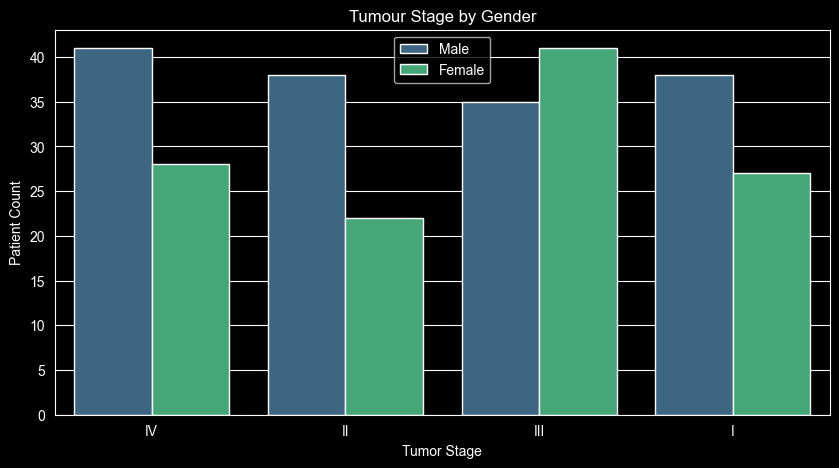

<Figure size 640x480 with 0 Axes>

In [79]:
#SECTION 4.1 +2

#importing required packages
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Tumor_Stage", hue="Gender", palette='viridis')
plt.title('Tumour Stage by Gender')
plt.xlabel('Tumor Stage')
plt.ylabel('Patient Count')
plt.legend()
plt.show()
plt.savefig('tumour_stage_gender.png')

#question 1: yes, the distribution of tumour stages differ by gender; males have a higher frequency of stage I, II and IV cancers, while females have a higher frequency of stage III cancers.


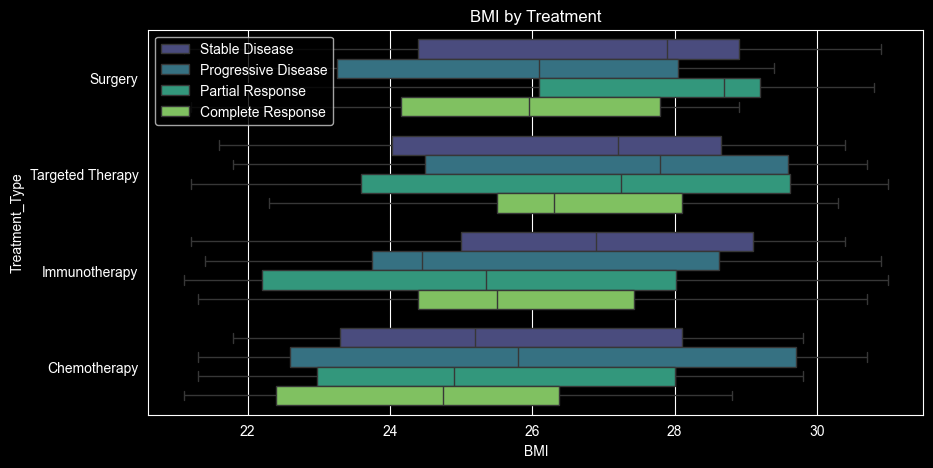

<Figure size 640x480 with 0 Axes>

In [80]:
#SECTION 4.3

#importing required packages
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data = df, x='BMI', y='Treatment_Type', hue='Response_to_Treatment', palette='viridis')
plt.title('BMI by Treatment')
plt.xlabel('BMI')
plt.legend(loc='upper left') #setting location of legend
plt.show()
plt.savefig('bmi_trial_drug.png')

#question 1: targeted therapy
#question 2: complete response tends to show slightly lower median BMI across most treatment types, whereas progressive or stable disease categories tend to have higher median BMI.

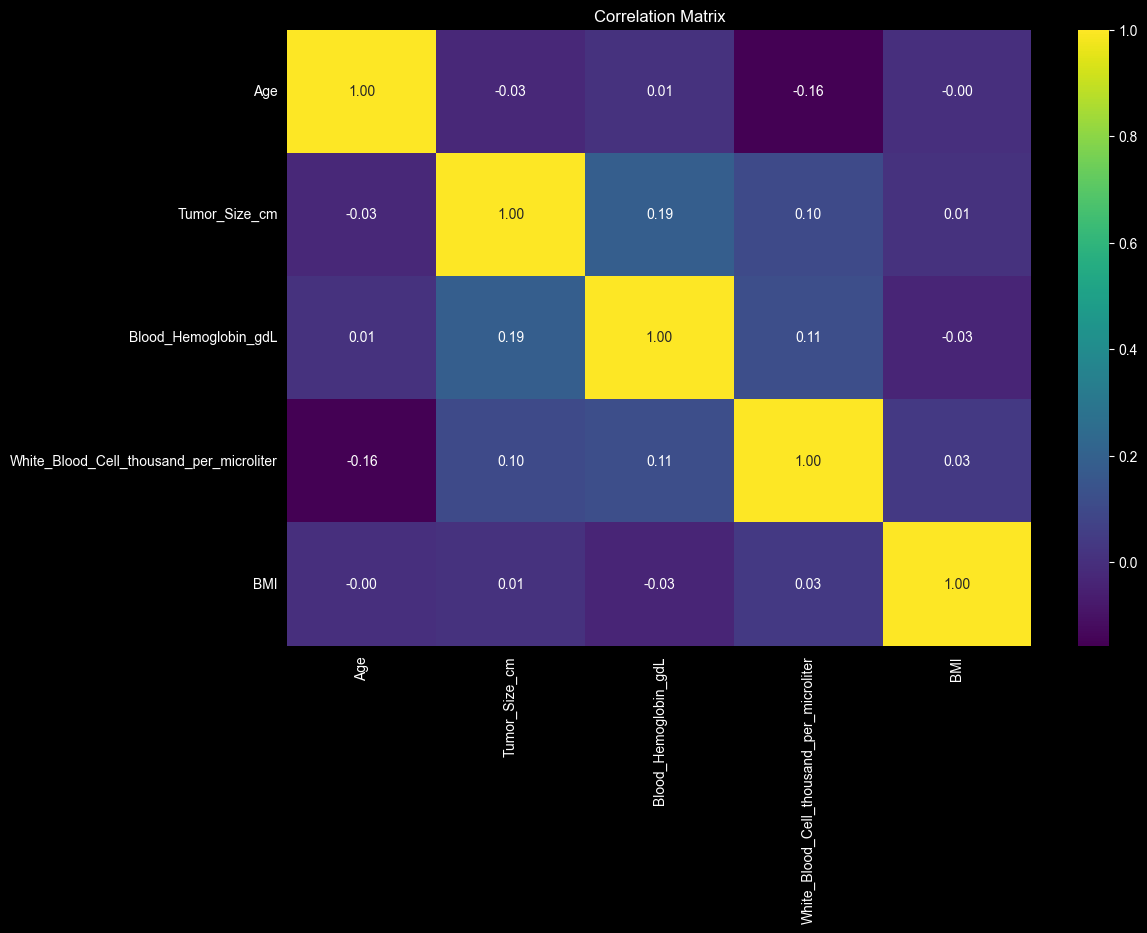

<Figure size 640x480 with 0 Axes>

In [81]:
#SECTION 4.4

#importing required packages
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = numerical_columns.corr() #creating correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', cmap='viridis') #.2f=to 2 decimal places
plt.title('Correlation Matrix')
plt.show()
plt.savefig('correlation_heatmap.png')

#question 1: relatively weak correlation across all the numerical values; negative correlation exist between age and WBC count and also blood haemoglobin and BMI.
#question 2: a weak positive correlation exists between blood haemoglobin and tumor size (r=0.19). Literature suggests that lower haemoglobin levels (anaemia) in cancer patients is generally associated with larger tumour sizes and poorer prognosis (Dunst. J, 2003), therefore a negative correlation would've been expected.

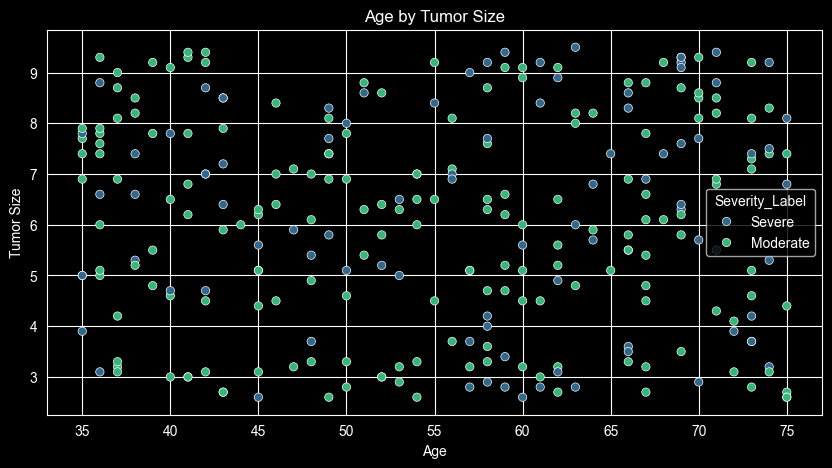

<Figure size 640x480 with 0 Axes>

In [82]:
#SECTION 4.5

#importing required packages
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Age', y='Tumor_Size_cm', hue='Severity_Label', palette='viridis')
plt.title('Age by Tumor Size')
plt.xlabel('Age')
plt.ylabel('Tumor Size')
plt.show()
plt.savefig('age_tumor_size.png')

#question 1: there is no clear clustering of patients with severe labels within a specific age or tumour size range


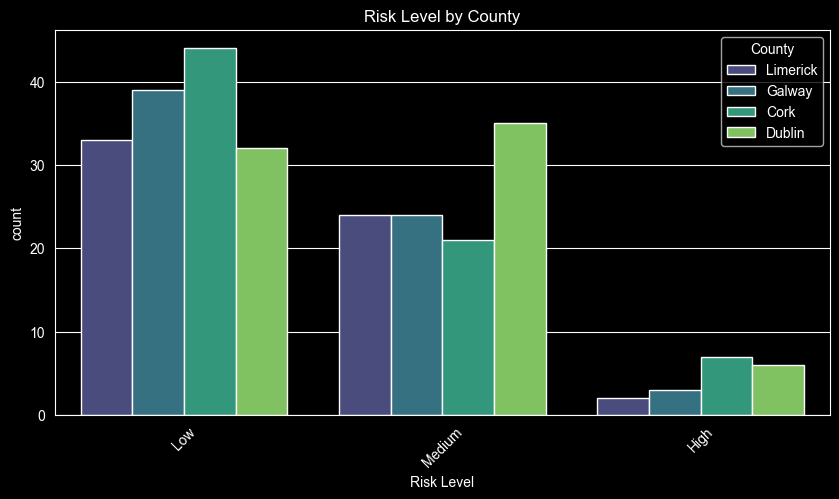

<Figure size 640x480 with 0 Axes>

In [83]:
#SECTION 4.6

#importing required packages
import seaborn as sns
import matplotlib.pyplot as plt

#sorting counts for county variable and specifying the index
county_count = df['County'].value_counts()
county_order = county_count.sort_values(ascending=True).index

#creating count plot
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Risk_Level', hue='County', hue_order=county_order, palette='viridis') # county_order was used to order the counties in the plot based on patient frequency
plt.title('Risk Level by County')
plt.xlabel('Risk Level')
plt.xticks(rotation=45) #rotating x-labels
plt.show()
plt.savefig('risk_level_county.png')

#question 1: Cork has the highest proportion of high-risk patients


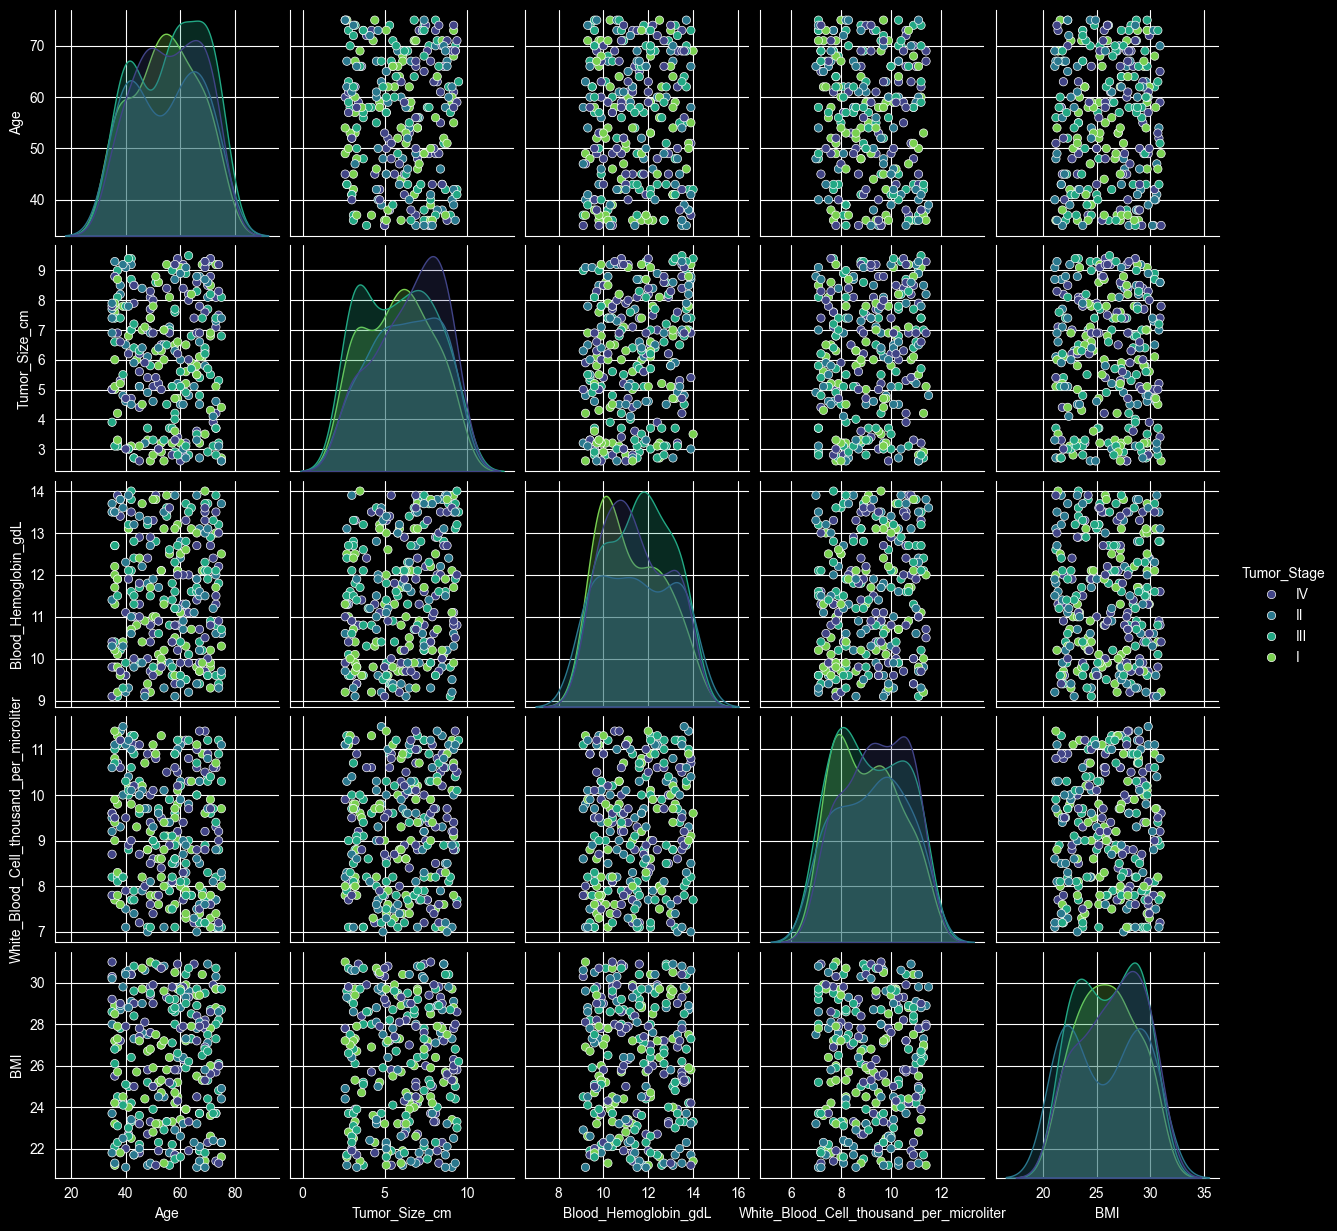

<Figure size 640x480 with 0 Axes>

In [84]:
#SECTION 4.7

#importing required packages
import seaborn as sns
import matplotlib.pyplot as plt

#ref: https://seaborn.pydata.org/generated/seaborn.pairplot.html

#creating pairplot with 'numerical_columns' as specific variables to use
sns.pairplot(data=df, vars=numerical_columns, hue='Tumor_Stage', palette='viridis')
plt.show()
plt.savefig('numerical_pairplot.png')


In [86]:
#SECTION 4.8

#checking to see if columns necessary columns are there
print(df.columns)
print(df.shape)

#exporting processed df to excel file
df.to_excel('lung_cancer_processed.xlsx', index=False)
print("directory contents:", os.listdir())

Index(['Age', 'Gender', 'Smoking_History', 'Family_History_Lung_Cancer',
       'Genetic_Mutation_EGFR', 'Genetic_Mutation_ALK', 'Tumor_Stage',
       'Tumor_Size_cm', 'Treatment_Type', 'Response_to_Treatment',
       'Blood_Hemoglobin_gdL', 'White_Blood_Cell_thousand_per_microliter',
       'Radiation_Exposure', 'Environmental_Exposure', 'Comorbidities', 'BMI',
       'County', 'Risk_Level', 'Severity_Label'],
      dtype='str')
(270, 19)
directory contents: ['.idea', '.venv', 'age_tumor_size.png', 'bmi_trial_drug.png', 'correlation_heatmap.png', 'LungCancerAnalysis.ipynb', 'lung_cancer_clinical_trial.csv', 'lung_cancer_processed.xlsx', 'numerical_pairplot.png', 'risk_level_county.png', 'tumour_stage_gender.png']


In [87]:
#Question 1

print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(270, 19)
Age                                         0
Gender                                      0
Smoking_History                             0
Family_History_Lung_Cancer                  0
Genetic_Mutation_EGFR                       0
Genetic_Mutation_ALK                        0
Tumor_Stage                                 0
Tumor_Size_cm                               0
Treatment_Type                              0
Response_to_Treatment                       0
Blood_Hemoglobin_gdL                        0
White_Blood_Cell_thousand_per_microliter    0
Radiation_Exposure                          0
Environmental_Exposure                      0
Comorbidities                               0
BMI                                         0
County                                      0
Risk_Level                                  0
Severity_Label                              0
dtype: int64
0


In [88]:
#Question 2
filtered_1 = df[df['Age']<65]
print(filtered_1.shape)
filtered_2 = filtered_1[filtered_1['Genetic_Mutation_EGFR'] == "Positive"]
print(filtered_2.shape)

#filtering desired data by age and mutation level
for i in filtered_2.index:
    print(f'County: {filtered_2.loc[i, "County"]}, BMI: {filtered_2.loc[i, "BMI"]}, Tumor stage: {filtered_2.loc[i, "Tumor_Stage"]}, Risk level: {filtered_2.loc[i, "Risk_Level"]}')
#iterating through these filtered rows to print county, BMI, tumor stage, and risk level

(191, 19)
(52, 19)
County: Cork, BMI: 23.3, Tumor stage: I, Risk level: Low
County: Cork, BMI: 21.8, Tumor stage: IV, Risk level: Medium
County: Galway, BMI: 26.4, Tumor stage: I, Risk level: Medium
County: Cork, BMI: 28.9, Tumor stage: I, Risk level: Medium
County: Dublin, BMI: 24.2, Tumor stage: I, Risk level: Low
County: Cork, BMI: 23.3, Tumor stage: III, Risk level: Low
County: Cork, BMI: 29.7, Tumor stage: I, Risk level: Low
County: Galway, BMI: 26.3, Tumor stage: IV, Risk level: Medium
County: Limerick, BMI: 25.0, Tumor stage: III, Risk level: Low
County: Limerick, BMI: 28.7, Tumor stage: II, Risk level: Medium
County: Cork, BMI: 23.9, Tumor stage: IV, Risk level: Low
County: Galway, BMI: 24.0, Tumor stage: I, Risk level: Low
County: Limerick, BMI: 30.5, Tumor stage: II, Risk level: Low
County: Limerick, BMI: 25.7, Tumor stage: I, Risk level: Medium
County: Dublin, BMI: 23.3, Tumor stage: III, Risk level: Medium
County: Limerick, BMI: 30.7, Tumor stage: III, Risk level: Medium
Co

In [89]:
#Question 3

table = summarize_risk_by_mutation(df, 'Genetic_Mutation_EGFR', 'Risk_Level')
print(table)
#the function is first called on this dataframe and columns
for i in range(len(table.index)):
    row_total = table.iloc[i].sum()
    for j in range(len(table.columns)):
        count = table.iloc[i, j]
        percent = (count / row_total) * 100
        print(f"Row: {table.index[i]}, Risk: {table.columns[j]}, Count: {count}, Percent: {percent:.2f}%")
#an iterating loop is made to go through these rows of the crosstabulated data to give the mutation, risk level, count of each risk level, and percentage that the count makes of that row

Risk_Level             High  Low  Medium
Genetic_Mutation_EGFR                   
Negative                  6   53      40
Positive                  3   42      27
Unknown                   9   53      37
Row: Negative, Risk: High, Count: 6, Percent: 6.06%
Row: Negative, Risk: Low, Count: 53, Percent: 53.54%
Row: Negative, Risk: Medium, Count: 40, Percent: 40.40%
Row: Positive, Risk: High, Count: 3, Percent: 4.17%
Row: Positive, Risk: Low, Count: 42, Percent: 58.33%
Row: Positive, Risk: Medium, Count: 27, Percent: 37.50%
Row: Unknown, Risk: High, Count: 9, Percent: 9.09%
Row: Unknown, Risk: Low, Count: 53, Percent: 53.54%
Row: Unknown, Risk: Medium, Count: 37, Percent: 37.37%
